## Importing Required Libraries

In [39]:
import cv2
import os
import numpy as np
import matplotlib.pyplot as plt

## Loading the Different Angles Images

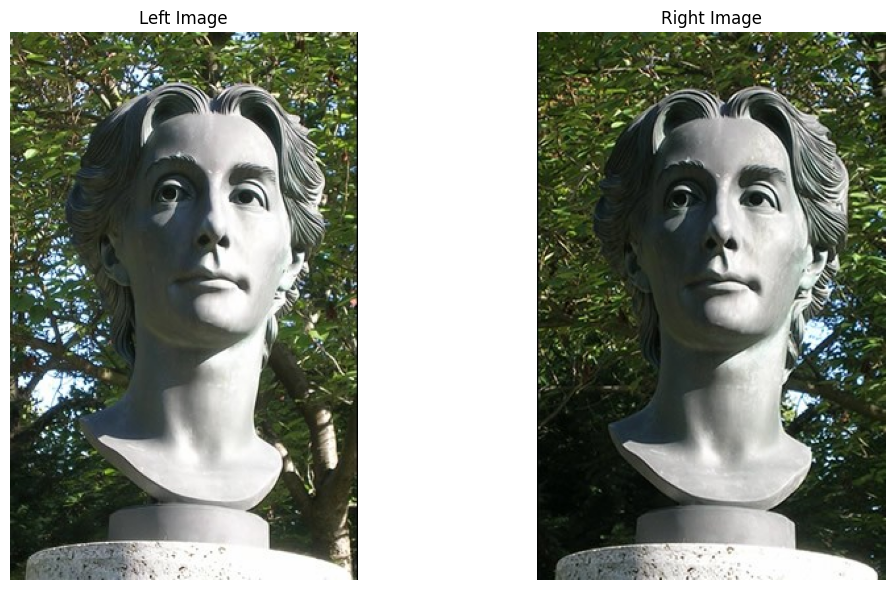

In [8]:
# Load images
l_image = cv2.imread('Left.jpg')
r_image = cv2.imread('Right.jpg')

# Convert BGR to RGB
Left_img_rgb = cv2.cvtColor(l_image, cv2.COLOR_BGR2RGB)
Right_img_rgb = cv2.cvtColor(r_image, cv2.COLOR_BGR2RGB)

# Create a figure with 1 row and 2 columns
fig, ax = plt.subplots(1, 2, figsize=(12, 6))

# Show Left Image
ax[0].imshow(Left_img_rgb)
ax[0].set_title("Left Image")
ax[0].axis('off')

# Show Right Image
ax[1].imshow(Right_img_rgb)
ax[1].set_title("Right Image")
ax[1].axis('off')

plt.tight_layout() # Adjusts spacing so titles don't overlap
plt.show()

## Resizing to Match Dimensions

In [13]:
# Check dimensions
print(f"Left: {l_image.shape}, Right: {r_image.shape}")

# If they don't match, resize the second to match the first
if l_image.shape != r_image.shape:
    height, width = l_image.shape[:2]
    r_image = cv2.resize(r_image, (width, height), interpolation=cv2.INTER_AREA)
    print("Images resized to match.")

Left: (416, 264, 3), Right: (416, 264, 3)


## Alignment (Image Registration)

In [32]:
def align_images(target_img, moving_img):
    # 1. Detect ORB features and descriptors
    orb = cv2.ORB_create(1000)
    kp1, des1 = orb.detectAndCompute(target_img, None)
    kp2, des2 = orb.detectAndCompute(moving_img, None)

    # 2. Match features using Brute-Force Matcher
    bf = cv2.BFMatcher(cv2.NORM_HAMMING, crossCheck=True)
    matches = bf.match(des1, des2)
    matches = sorted(matches, key=lambda x: x.distance)

    # 3. Extract location of good matches
    points1 = np.zeros((len(matches), 2), dtype=np.float32)
    points2 = np.zeros((len(matches), 2), dtype=np.float32)

    for i, match in enumerate(matches):
        points1[i, :] = kp1[match.queryIdx].pt
        points2[i, :] = kp2[match.trainIdx].pt

    # 4. Find Homography matrix
    h, mask = cv2.findHomography(points2, points1, cv2.RANSAC)

    # 5. Use homography to warp image
    height, width = target_img.shape[:2]
    aligned_img = cv2.warpPerspective(moving_img, h, (width, height))
    
    return aligned_img

# Usage
r_image_aligned = align_images(l_image, r_image)

## Converting to Grayscale

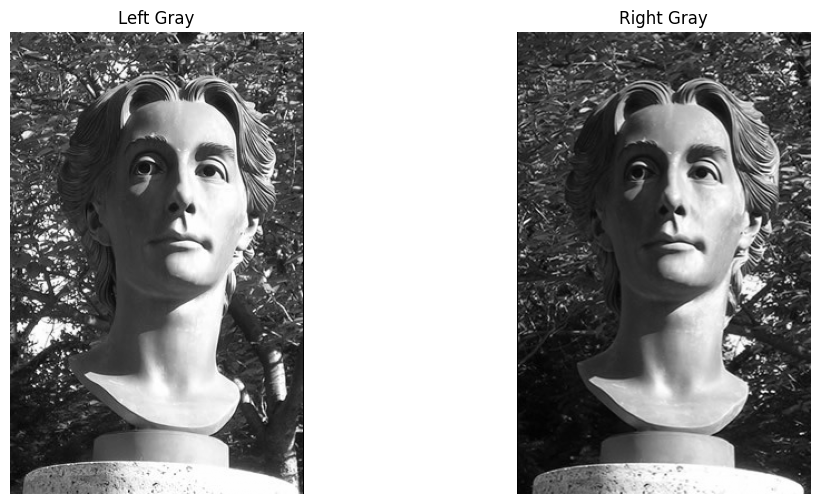

In [44]:
left_gray = cv2.cvtColor(l_image, cv2.COLOR_BGR2GRAY)
right_gray_aligned = cv2.cvtColor(r_image_aligned, cv2.COLOR_BGR2GRAY)

fig, ax = plt.subplots(1, 2, figsize=(12, 6))

ax[0].imshow(left_gray, cmap='gray')
ax[0].set_title("Left Gray")
ax[0].axis('off')

ax[1].imshow(right_gray, cmap='gray')
ax[1].set_title("Right Gray")
ax[1].axis('off')

plt.show()

(np.float64(-0.5), np.float64(263.5), np.float64(415.5), np.float64(-0.5))

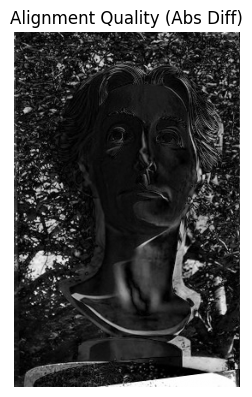

In [50]:
plt.subplot(1, 2, 1)
plt.imshow(cv2.absdiff(left_gray, right_gray_aligned), cmap='gray')
plt.title("Alignment Quality (Abs Diff)")
plt.axis('off')

## Shift Estimator:
This module will do the heavy lifting. It takes the two preprocessed images and calculates the horizontal shift (disparity) for each pixel or block of pixels.

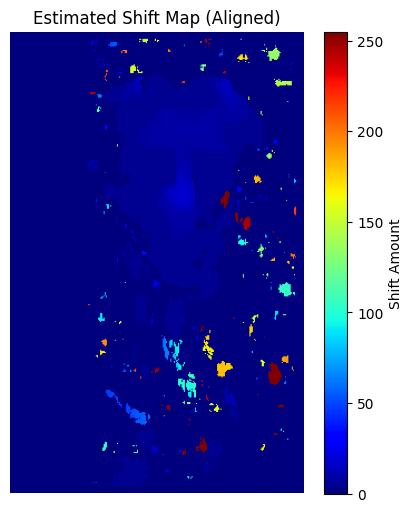

In [51]:
stereo_sgbm = cv2.StereoSGBM_create(
    minDisparity=0,
    numDisparities=16*4,
    blockSize=5,
    P1=8 * 3 * 5**2,    # Penalty for small changes
    P2=32 * 3 * 5**2,   # Penalty for large changes
    disp12MaxDiff=1,
    uniquenessRatio=10,
    speckleWindowSize=100,
    speckleRange=32
)

disparity_sgbm = stereo_sgbm.compute(left_gray, right_gray_aligned)

# 6. Normalize for visualization
disparity_vis = cv2.normalize(disparity, None, alpha=0, beta=255, 
                              norm_type=cv2.NORM_MINMAX, dtype=cv2.CV_8U)

# 7. Display results
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 2)
plt.imshow(disparity_vis, cmap='jet')
plt.colorbar(label='Shift Amount')
plt.title("Estimated Shift Map (Aligned)")
plt.axis('off')

plt.show()

## Depth Normalizer:
The raw shift values won't be in a 0-255 visual range. This module takes the raw disparity data and normalizes it so that the maximum shift becomes pure white (closest) and the minimum shift becomes pure black (farthest), exactly as your assignment requires.

In [46]:
def normalize_depth(disparity_map):
    # 1. Handle invalid pixels 
    # OpenCV often marks pixels it couldn't match with -16 or -1
    disparity_map[disparity_map < 0] = 0
    
    # 2. Normalize to 0-255
    # We use CV_8U to ensure it's compatible with standard image formats
    normalized = cv2.normalize(src=disparity_map, dst=None, 
                               alpha=0, beta=255, 
                               norm_type=cv2.NORM_MINMAX, 
                               dtype=cv2.CV_8U)
    
    return normalized

In [53]:
def visualize_and_save(image_data, filename="depth_map.png", folder="output"):
    
    # 1. Create directory if it doesn't exist
    if not os.path.exists(folder):
        os.makedirs(folder)
    
    # 2. Save the file
    filepath = os.path.join(folder, filename)
    cv2.imwrite(filepath, image_data)
    print(f"Success: Image saved to {filepath}")
    
    # 3. Display in Jupyter
    plt.figure(figsize=(8, 8))
    plt.imshow(image_data, cmap='gray')
    plt.title("Normalized Depth Map")
    plt.axis('off')
    plt.show()

Success: Image saved to output/Result.png


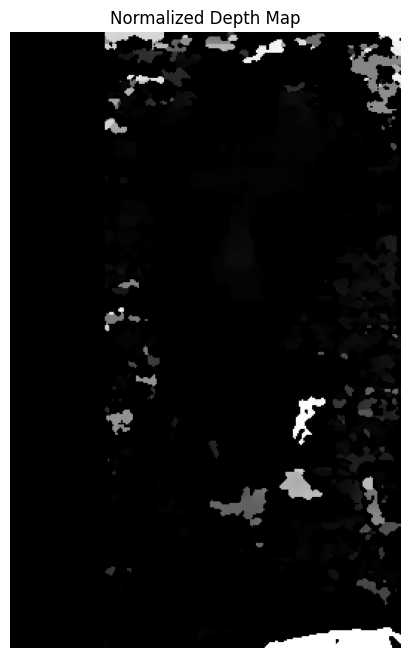

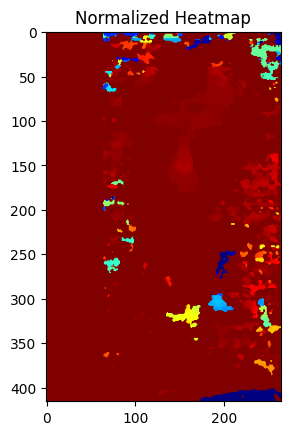

In [56]:
# 1. Calculate raw disparity (using the code from your previous cell)
raw_disparity = stereo_sgbm.compute(left_gray, right_gray_aligned)

# 2. Normalize the shift values
final_depth_map = normalize_depth(raw_disparity)

# 3. Visualize and Export
visualize_and_save(final_depth_map, filename="Result.png")

# Apply a JET or MAGMA colormap to the grayscale result
heatmap = cv2.applyColorMap(final_depth_map, cv2.COLORMAP_JET)
plt.title("Normalized Heatmap")
plt.imshow(heatmap)